# Earthquake Location and Relocation

<a target="_blank" href="https://colab.research.google.com/github/AI4EPS/EPS130_Seismology/blob/main/notebooks/earthquake_location_lecture.ipynb">
<img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>

This notebook demonstrates earthquake location concepts with simple 2D examples.
By the end, you should understand:

1. **Linear inversion for earthquake location**: how we set up $\mathbf{d} = \mathbf{G}\,\Delta\mathbf{m}$ and solve via least squares
2. **Uncertainty quantification**: how station geometry and data noise determine location uncertainty (error ellipse, $\chi^2$ test)
3. **Relocation**: how double-difference and station terms improve relative locations using the same mathematical framework

---
## Setup

Run this cell to load libraries and set up the problem geometry.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import lsqr
from scipy.stats import chi2
import io, sys

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# Physical parameters
v_true = 6.0       # km/s, uniform velocity
sigma_true = 0.05  # picking noise standard deviation (s)

# True earthquake location (unknown to us in practice)
x0_true, z0_true, t0_true = 5.0, 8.0, 0.0

# Station positions (all at the surface, z=0)
station_x = np.array([-5, -2, 0, 3, 6, 10, 13, 15], dtype=float)
station_z = np.zeros_like(station_x)
n_stations = len(station_x)

# Plotting utility — draws an ellipse from a 2x2 covariance matrix
def plot_error_ellipse(ax, Cm_2d, center, n_std=2, **kwargs):
    eigvals, eigvecs = np.linalg.eigh(Cm_2d)
    angle = np.degrees(np.arctan2(eigvecs[1, 1], eigvecs[0, 1]))
    width  = 2 * n_std * np.sqrt(max(eigvals[1], 0))
    height = 2 * n_std * np.sqrt(max(eigvals[0], 0))
    ell = Ellipse(xy=center, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ell)

print(f"Stations: {n_stations} at surface, x = {station_x}")
print(f"Velocity = {v_true} km/s, noise sigma = {sigma_true} s")

Stations: 8 at surface, x = [-5. -2.  0.  3.  6. 10. 13. 15.]
Velocity = 6.0 km/s, noise sigma = 0.05 s


---
## 1. Forward Function and Geometry

The **forward function** predicts the arrival time at station $i$:

$$\hat{t}^i = \frac{\sqrt{(x^i - x_0)^2 + (z^i - z_0)^2}}{v} + t_0$$

This is the core of earthquake location: given a source position, predict what the data should look like.
The **inverse problem** is the reverse: given observed arrival times, find the source position.

The left panel shows the geometry (source + stations + ray paths).
The right panel shows the travel time curve — observed times have noise added.

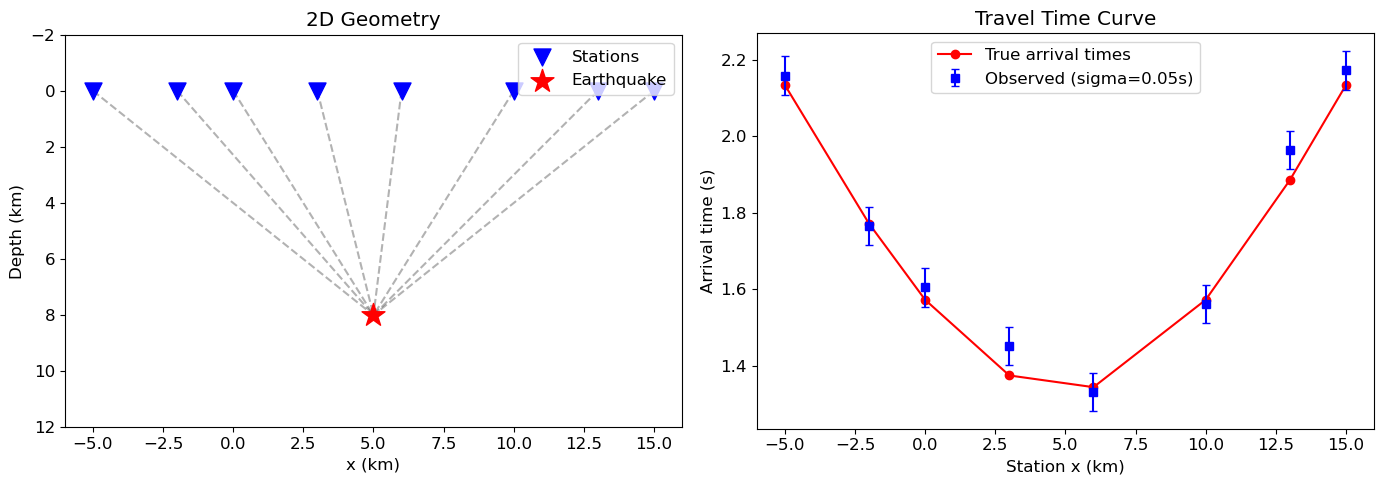

In [2]:
def forward(x0, z0, t0, v, sx, sz):
    """Predict arrival time at each station: t = distance/velocity + origin_time."""
    dist = np.sqrt((sx - x0)**2 + (sz - z0)**2)
    return dist / v + t0

# Synthetic data: compute true times, then add random noise to simulate picking errors
t_true = forward(x0_true, z0_true, t0_true, v_true, station_x, station_z)
t_obs  = t_true + np.random.normal(0, sigma_true, n_stations)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(station_x, np.zeros_like(station_x), marker="v", s=150, c="blue", zorder=5, label="Stations")
ax.scatter(x0_true, z0_true, marker="*", s=300, c="red", zorder=5, label="Earthquake")
for i in range(n_stations):
    ax.plot([station_x[i], x0_true], [0, z0_true], "k--", alpha=0.3)
ax.set_xlabel("x (km)"); ax.set_ylabel("Depth (km)")
ax.set_title("2D Geometry"); ax.legend(loc="upper right")
ax.set_ylim(12, -2); ax.set_aspect("equal")

ax = axes[1]
ax.plot(station_x, t_true, "ro-", label="True arrival times")
ax.errorbar(station_x, t_obs, yerr=sigma_true, fmt="bs", capsize=3, label=f"Observed (sigma={sigma_true}s)")
ax.set_xlabel("Station x (km)"); ax.set_ylabel("Arrival time (s)")
ax.set_title("Travel Time Curve"); ax.legend()

plt.tight_layout(); plt.show()

---
## 2. Loss Functions

To find the best location, we need a **loss function** that measures how well our predicted times match the observations.

- **L2 (least squares)**: $L = \sum r_i^2$ — smooth, standard choice, but sensitive to outliers
- **L1**: $L = \sum |r_i|$ — robust to outliers, but not differentiable at zero
- **Huber**: combines L2 near zero with L1 far away — best of both worlds

In earthquake location, **L2 is standard** because it leads to a simple linear algebra solution.

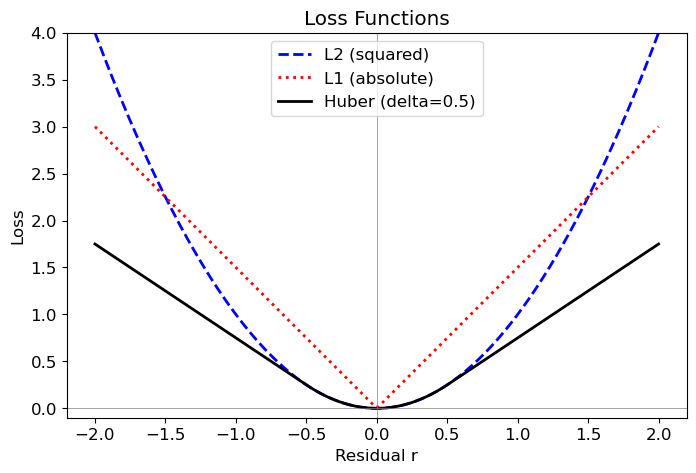

L2: smooth, has closed-form solution, but outliers dominate
L1: robust to outliers, but not differentiable at r=0
Huber: smooth near zero (like L2), linear far away (like L1)


In [3]:
r = np.linspace(-2, 2, 200)
delta = 0.5

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(r, r**2, "b--", lw=2, label="L2 (squared)")
ax.plot(r, np.abs(r) * 1.5, "r:", lw=2, label="L1 (absolute)")
huber = np.where(np.abs(r) <= delta, r**2, 2 * delta * (np.abs(r) - delta / 2))
ax.plot(r, huber, "k-", lw=2, label=f"Huber (delta={delta})")
ax.set_xlabel("Residual r"); ax.set_ylabel("Loss"); ax.set_title("Loss Functions")
ax.legend(); ax.set_ylim(-0.1, 4)
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
plt.show()

print("L2: smooth, has closed-form solution, but outliers dominate")
print("L1: robust to outliers, but not differentiable at r=0")
print("Huber: smooth near zero (like L2), linear far away (like L1)")

---
## 3. Linearization and the Jacobian

The forward function $\hat{t}^i = f^i(\mathbf{m})$ is **nonlinear** in $(x_0, z_0)$.
To use linear algebra, we **Taylor expand** around an initial guess $\mathbf{m}_0$:

$$f^i(\mathbf{m}_0 + \Delta\mathbf{m}) \approx f^i(\mathbf{m}_0) + \frac{\partial f^i}{\partial m_j} \Delta m_j$$

This gives us a **linear system**: $\mathbf{r}_0 = \mathbf{G} \, \Delta\mathbf{m}$

where:
- $\mathbf{r}_0 = \mathbf{t}_{\text{obs}} - \mathbf{t}_{\text{pred}}$ is the residual vector
- $\mathbf{G}$ is the **Jacobian matrix** ($n_{\text{stations}} \times 3$)
- $\Delta\mathbf{m} = (\Delta x_0, \Delta z_0, \Delta t_0)$ is the model update

Each row of $\mathbf{G}$ contains the **partial derivatives** of the travel time with respect to each parameter.
Note that $\partial t / \partial t_0 = 1$ for every station (origin time shifts all arrivals equally).

In [4]:
def compute_jacobian(x0, z0, v, sx, sz):
    """Jacobian matrix G (n_stations x 3).
    Row i  = how arrival time at station i changes when we move the source.
    Col 0  = dt/dx0, Col 1 = dt/dz0, Col 2 = dt/dt0.
    """
    dist  = np.sqrt((sx - x0)**2 + (sz - z0)**2)
    dtdx  = -(sx - x0) / (v * dist)         # negative: moving source toward station decreases time
    dtdz  = -(sz - z0) / (v * dist)
    dtdt0 = np.ones_like(sx, dtype=float)    # shifting origin time shifts all arrivals by the same amount
    return np.column_stack([dtdx, dtdz, dtdt0])

# Evaluate the Jacobian at a wrong initial guess to see what it looks like
x0_init, z0_init, t0_init = 2.0, 5.0, 0.5
G  = compute_jacobian(x0_init, z0_init, v_true, station_x, station_z)
r0 = t_obs - forward(x0_init, z0_init, t0_init, v_true, station_x, station_z)

print("Jacobian G (n_stations x 3): columns = [dt/dx0, dt/dz0, dt/dt0]")
print("-" * 65)
for i in range(n_stations):
    print(f"  Station {i} (x={station_x[i]:5.1f}): [{G[i,0]:+.4f}, {G[i,1]:+.4f}, {G[i,2]:+.0f}]  r0={r0[i]:+.4f}s")

print()
print("Look at the columns:")
print("  dt/dt0 = 1 for ALL stations  -> origin time is coupled with every station equally")
print("  dt/dz0 same sign for all     -> all rays go down, so moving source deeper changes all times the same way")
print("  dt/dx0 changes sign          -> stations on opposite sides respond oppositely to horizontal shifts")
print()
print("This is why horizontal location is well constrained but depth is not.")

Jacobian G (n_stations x 3): columns = [dt/dx0, dt/dz0, dt/dt0]
-----------------------------------------------------------------
  Station 0 (x= -5.0): [+0.1356, +0.0969, +1]  r0=+0.2255s
  Station 1 (x= -2.0): [+0.1041, +0.1301, +1]  r0=+0.1976s
  Station 2 (x=  0.0): [+0.0619, +0.1547, +1]  r0=+0.2072s
  Station 3 (x=  3.0): [-0.0327, +0.1634, +1]  r0=+0.1007s
  Station 4 (x=  6.0): [-0.1041, +0.1301, +1]  r0=-0.2352s
  Station 5 (x= 10.0): [-0.1413, +0.0883, +1]  r0=-0.5117s
  Station 6 (x= 13.0): [-0.1517, +0.0690, +1]  r0=-0.5493s
  Station 7 (x= 15.0): [-0.1556, +0.0598, +1]  r0=-0.6487s

Look at the columns:
  dt/dt0 = 1 for ALL stations  -> origin time is coupled with every station equally
  dt/dz0 same sign for all     -> all rays go down, so moving source deeper changes all times the same way
  dt/dx0 changes sign          -> stations on opposite sides respond oppositely to horizontal shifts

This is why horizontal location is well constrained but depth is not.


---
## 4. Geiger's Method: Iterative Least Squares

Since the linearization is only valid near the current guess, we **iterate**:

1. Start with initial guess $\mathbf{m}_0$
2. Compute residuals $\mathbf{r}$ and Jacobian $\mathbf{G}$ at $\mathbf{m}_0$
3. Solve: $\Delta\mathbf{m} = (\mathbf{G}^T\mathbf{G})^{-1}\mathbf{G}^T\mathbf{r}$
4. Update: $\mathbf{m}_0 \leftarrow \mathbf{m}_0 + \Delta\mathbf{m}$
5. Repeat until converged

This is **Geiger's method** (1912) — the foundation of most earthquake location software.
The left panel shows the convergence path from initial guess to true location.
The right panel shows the RMS residual decreasing with each iteration.

  Iter 1: x=4.2898, z=8.8674, t0=-0.0019, |dm|=4.522347
  Iter 2: x=4.9820, z=7.8103, t0=0.0580, |dm|=1.264926
  Iter 3: x=4.9416, z=7.7955, t0=0.0546, |dm|=0.043172
  Iter 4: x=4.9416, z=7.7983, t0=0.0543, |dm|=0.002753
  Iter 5: x=4.9416, z=7.7983, t0=0.0543, |dm|=0.000020
  Iter 6: x=4.9416, z=7.7983, t0=0.0543, |dm|=0.000001


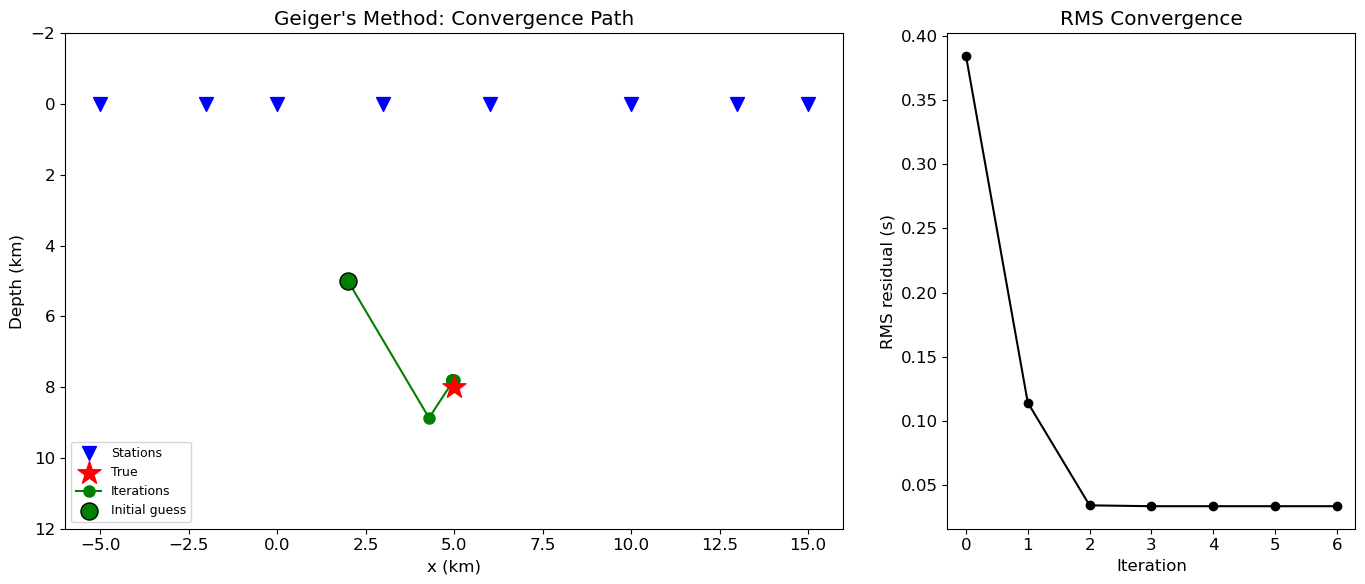

In [5]:
def geiger_method(x0, z0, t0, v, sx, sz, t_obs, max_iter=20, tol=1e-6, verbose=True):
    """Geiger's method: iteratively solve the linearized location problem.
    Each iteration: predict -> residual -> Jacobian -> least squares -> update.
    """
    history = [(x0, z0, t0)]
    for it in range(max_iter):
        t_pred = forward(x0, z0, t0, v, sx, sz)       # 1. predict times at current guess
        r = t_obs - t_pred                              # 2. residual = data - prediction
        G = compute_jacobian(x0, z0, v, sx, sz)         # 3. Jacobian at current guess
        dm = np.linalg.lstsq(G, r, rcond=None)[0]      # 4. least squares solve for model update
        x0 += dm[0]; z0 += dm[1]; t0 += dm[2]          # 5. update the guess
        history.append((x0, z0, t0))
        if verbose:
            print(f"  Iter {it+1}: x={x0:.4f}, z={z0:.4f}, t0={t0:.4f}, |dm|={np.linalg.norm(dm):.6f}")
        if np.linalg.norm(dm) < tol:
            break
    return x0, z0, t0, G, np.array(history)

x0_est, z0_est, t0_est, G_final, history = geiger_method(
    x0_init, z0_init, t0_init, v_true, station_x, station_z, t_obs)

# --- Plot ---
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[2, 1])

ax = fig.add_subplot(gs[0])
ax.scatter(station_x, np.zeros(n_stations), marker="v", s=100, c="blue", zorder=5, label="Stations")
ax.scatter(x0_true, z0_true, marker="*", s=300, c="red", zorder=5, label="True")
ax.plot(history[:, 0], history[:, 1], "go-", markersize=8, label="Iterations")
ax.scatter(history[0, 0], history[0, 1], s=150, c="green", edgecolors="k", zorder=6, label="Initial guess")
ax.set_xlabel("x (km)"); ax.set_ylabel("Depth (km)")
ax.set_title("Geiger's Method: Convergence Path")
ax.legend(fontsize=9); ax.set_ylim(12, -2); ax.set_aspect("equal")

ax2 = fig.add_subplot(gs[1])
rms = [np.sqrt(np.mean((t_obs - forward(h[0], h[1], h[2], v_true, station_x, station_z))**2)) for h in history]
ax2.plot(range(len(rms)), rms, "ko-")
ax2.set_xlabel("Iteration"); ax2.set_ylabel("RMS residual (s)")
ax2.set_title("RMS Convergence")

plt.tight_layout(); plt.show()

---
## 5. Grid Search (NonLinLoc-style)

An alternative to Geiger's method: evaluate the misfit at **every point** on a grid.
This avoids linearization and local minima, but is much slower.

**NonLinLoc** (Lomax et al., 2000) uses this approach with efficient Oct-Tree sampling.
Notice the elongated valley in the depth direction — this confirms that depth is poorly constrained.

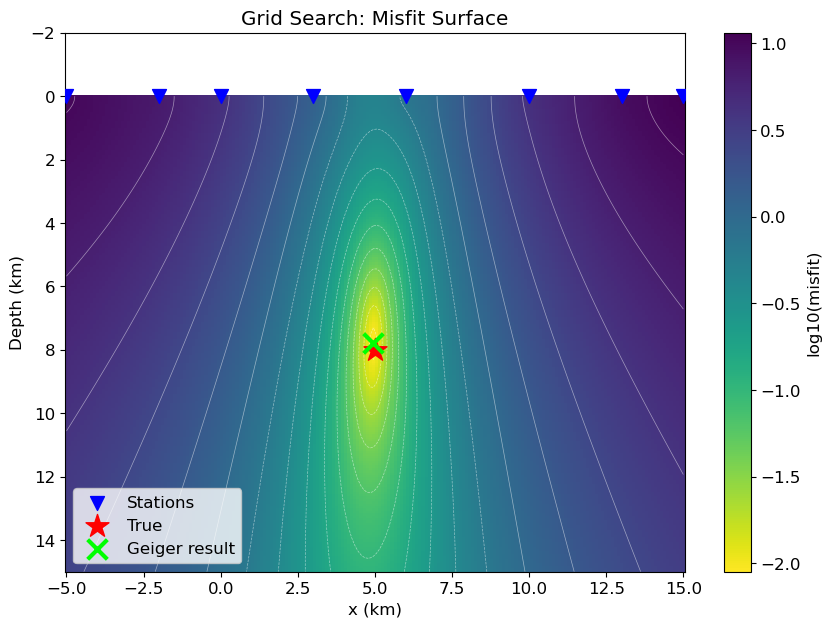

The elongated valley in depth confirms: depth is poorly constrained!


In [6]:
x_grid = np.linspace(-5, 15, 200)
z_grid = np.linspace(0, 15, 200)
X, Z = np.meshgrid(x_grid, z_grid)
misfit = np.zeros_like(X)

# Evaluate misfit at every grid point (brute force)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        dist = np.sqrt((station_x - X[i, j])**2 + Z[i, j]**2)
        t0_opt = np.mean(t_obs - dist / v_true)  # best-fit origin time at this grid point
        misfit[i, j] = np.sum((t_obs - dist / v_true - t0_opt)**2)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.pcolormesh(X, Z, np.log10(misfit), cmap="viridis_r", shading="auto")
ax.contour(X, Z, np.log10(misfit), levels=15, colors="white", linewidths=0.5, alpha=0.5)
ax.scatter(station_x, np.zeros(n_stations), marker="v", s=100, c="blue", zorder=5, label="Stations")
ax.scatter(x0_true, z0_true, marker="*", s=300, c="red", zorder=5, label="True")
ax.scatter(x0_est, z0_est, marker="x", s=200, c="lime", lw=3, zorder=5, label="Geiger result")
plt.colorbar(im, label="log10(misfit)")
ax.set_xlabel("x (km)"); ax.set_ylabel("Depth (km)")
ax.set_title("Grid Search: Misfit Surface"); ax.legend(); ax.set_ylim(15, -2)
plt.show()

print("The elongated valley in depth confirms: depth is poorly constrained!")

---
## 6. Uncertainty: The Error Ellipse

At the solution, the **model covariance matrix** tells us the uncertainty:

$$\mathbf{C}_m = (\mathbf{G}^T \mathbf{G})^{-1} \, \sigma^2$$

where $\sigma$ is the data noise (picking error). The covariance matrix defines an **error ellipse**:
- The axes of the ellipse point along the directions of maximum/minimum uncertainty
- The axis lengths are proportional to $\sigma_x, \sigma_z$ (square roots of the diagonal of $\mathbf{C}_m$)
- Off-diagonal terms capture **correlated** uncertainties (e.g., depth--origin time tradeoff)

Estimated sigma: 0.0423 s  (true: 0.05 s)
sigma_x  = 0.1507 km
sigma_z  = 0.6574 km  (larger — depth poorly constrained)
sigma_t0 = 0.0878 s


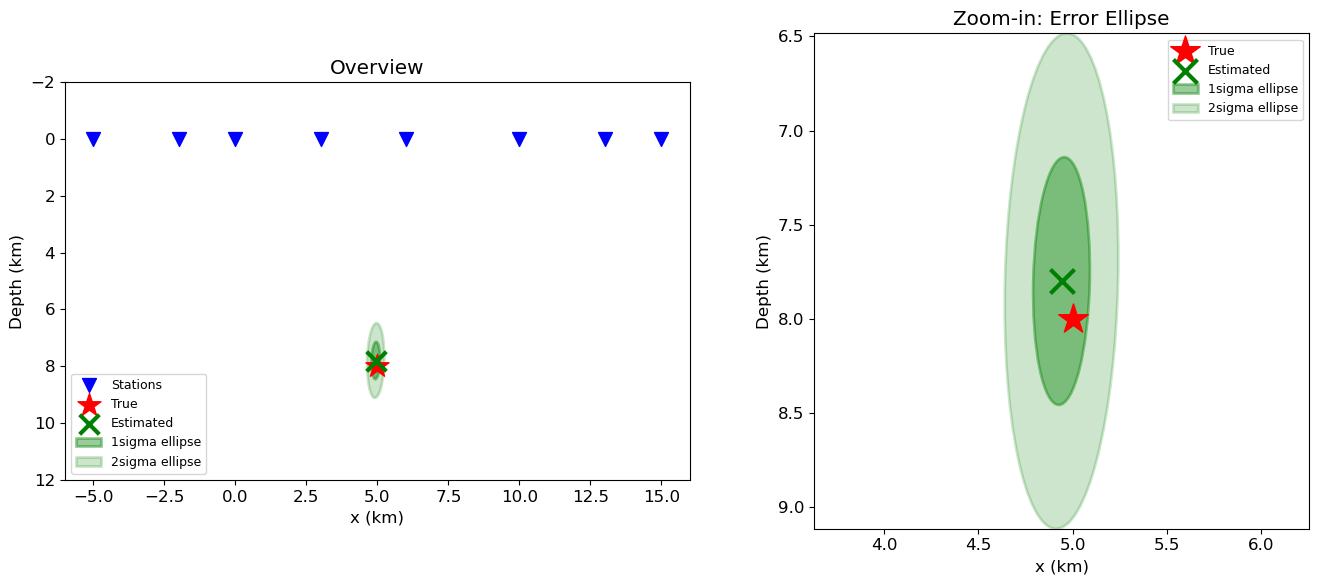

In [7]:
# Jacobian and residuals at the best-fit location
G_final = compute_jacobian(x0_est, z0_est, v_true, station_x, station_z)
r_final = t_obs - forward(x0_est, z0_est, t0_est, v_true, station_x, station_z)
n_params = 3  # x, z, t0

# In practice we don't know sigma, so estimate it from the residuals:
# sigma^2 = sum(r^2) / (n_observations - n_parameters)
sigma_est = np.sqrt(np.sum(r_final**2) / (n_stations - n_params))

# Covariance matrix: tells us how uncertain each parameter is
# C_m = (G^T G)^{-1} * sigma^2
Cm = np.linalg.inv(G_final.T @ G_final) * sigma_est**2

print(f"Estimated sigma: {sigma_est:.4f} s  (true: {sigma_true} s)")
print(f"sigma_x  = {np.sqrt(Cm[0,0]):.4f} km")
print(f"sigma_z  = {np.sqrt(Cm[1,1]):.4f} km  (larger — depth poorly constrained)")
print(f"sigma_t0 = {np.sqrt(Cm[2,2]):.4f} s")

# Extract the x-z block for the 2D error ellipse (ignoring the t0 dimension)
Cm_xz = Cm[:2, :2].copy()

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(station_x, np.zeros(n_stations), marker="v", s=100, c="blue", zorder=5, label="Stations")
ax.scatter(x0_true, z0_true, marker="*", s=300, c="red", zorder=5, label="True")
ax.scatter(x0_est, z0_est, marker="x", s=200, c="green", lw=3, zorder=5, label="Estimated")
for ns, alpha in [(1, 0.4), (2, 0.2)]:
    plot_error_ellipse(ax, Cm_xz, (x0_est, z0_est), n_std=ns,
                       fill=True, facecolor="green", alpha=alpha, edgecolor="green", lw=2, label=f"{ns}sigma ellipse")
ax.set_xlabel("x (km)"); ax.set_ylabel("Depth (km)")
ax.set_title("Overview"); ax.legend(fontsize=9); ax.set_ylim(12, -2); ax.set_aspect("equal")

ax = axes[1]
ax.scatter(x0_true, z0_true, marker="*", s=500, c="red", zorder=5, label="True")
ax.scatter(x0_est, z0_est, marker="x", s=300, c="green", lw=3, zorder=5, label="Estimated")
for ns, alpha in [(1, 0.4), (2, 0.2)]:
    plot_error_ellipse(ax, Cm_xz, (x0_est, z0_est), n_std=ns,
                       fill=True, facecolor="green", alpha=alpha, edgecolor="green", lw=2, label=f"{ns}sigma ellipse")
margin = max(2 * np.sqrt(Cm_xz[0, 0]), 2 * np.sqrt(Cm_xz[1, 1]), 0.5)
ax.set_xlim(x0_est - margin, x0_est + margin)
ax.set_ylim(z0_est + margin, z0_est - margin)
ax.set_xlabel("x (km)"); ax.set_ylabel("Depth (km)")
ax.set_title("Zoom-in: Error Ellipse"); ax.legend(fontsize=9); ax.set_aspect("equal")

plt.tight_layout(); plt.show()

---
## 7. Singular Value Decomposition (SVD)

SVD decomposes the Jacobian: $\mathbf{G} = \mathbf{U} \mathbf{S} \mathbf{V}^T$

The **singular values** ($s_1, s_2, s_3$) tell us how well each direction in model space is resolved:
- **Large** $s_i$: data respond strongly $\Rightarrow$ well constrained
- **Small** $s_i$: data barely respond $\Rightarrow$ poorly constrained

The columns of $\mathbf{V}$ define the **directions** (combinations of $\Delta x, \Delta z, \Delta t_0$).

The covariance matrix can be written as $\mathbf{C}_m = \mathbf{V} \mathbf{S}^{-2} \mathbf{V}^T \sigma^2$,
so small singular values lead to large uncertainties.

SVD of G (8x3):
  U: (8, 3), S: diag([2.8528 0.282  0.0638]), V: (3, 3)

  s_1 = 2.8528,  direction = (-0.001*dx, -0.131*dz, -0.991*dt0)
    uncertainty amplification 1/s^2 = 0.1229

  s_2 = 0.2820,  direction = (-1.000*dx, -0.023*dz, +0.004*dt0)
    uncertainty amplification 1/s^2 = 12.5767

  s_3 = 0.0638,  direction = (+0.023*dx, -0.991*dz, +0.130*dt0)
    uncertainty amplification 1/s^2 = 245.9023

Smallest singular value => depth+origin_time direction => largest uncertainty


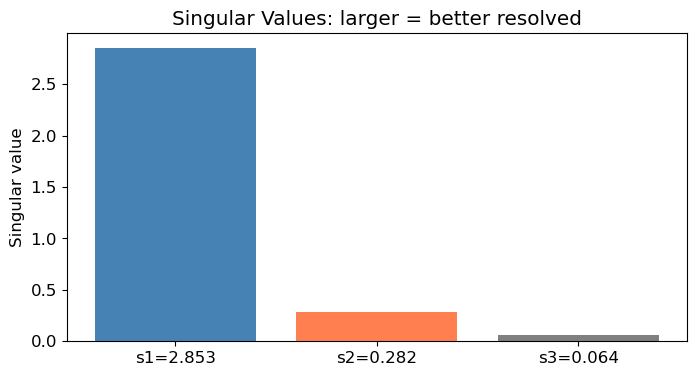

In [8]:
# SVD: G = U S V^T
U, s, Vt = np.linalg.svd(G_final, full_matrices=False)

print(f"SVD of G ({G_final.shape[0]}x{G_final.shape[1]}):")
print(f"  U: {U.shape}, S: diag({np.round(s, 4)}), V: {Vt.T.shape}")
print()
for i in range(3):
    v_dir = Vt[i]
    print(f"  s_{i+1} = {s[i]:.4f},  direction = ({v_dir[0]:+.3f}*dx, {v_dir[1]:+.3f}*dz, {v_dir[2]:+.3f}*dt0)")
    print(f"    uncertainty amplification 1/s^2 = {1/s[i]**2:.4f}")
    print()

print("Smallest singular value => depth+origin_time direction => largest uncertainty")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(3), s, color=["steelblue", "coral", "gray"])
ax.set_xticks(range(3))
ax.set_xticklabels([f"s1={s[0]:.3f}", f"s2={s[1]:.3f}", f"s3={s[2]:.3f}"])
ax.set_ylabel("Singular value"); ax.set_title("Singular Values: larger = better resolved")
plt.show()

---
## 8. Station Geometry Effects

The uncertainty $\mathbf{C}_m = (\mathbf{G}^T\mathbf{G})^{-1}\sigma^2$ depends on $\mathbf{G}$, which depends on **station-source geometry**.

We compare four configurations:
1. **Good coverage**: 8 stations surrounding the source
2. **Azimuthal gap**: all stations on one side → elongated ellipse
3. **Few stations**: only 4 stations → larger uncertainty
4. **Borehole sensor**: one station at depth → much better depth constraint

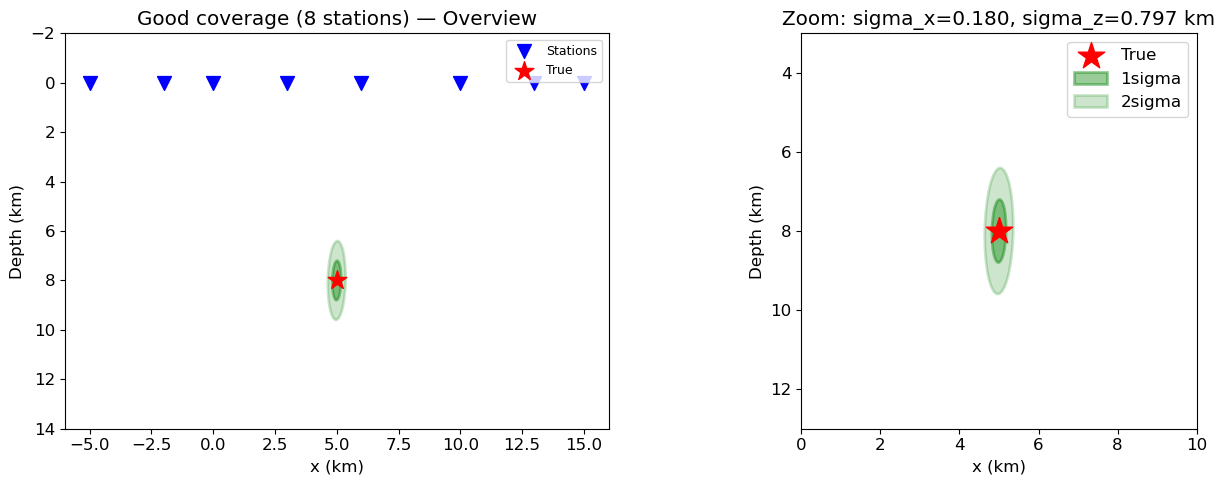

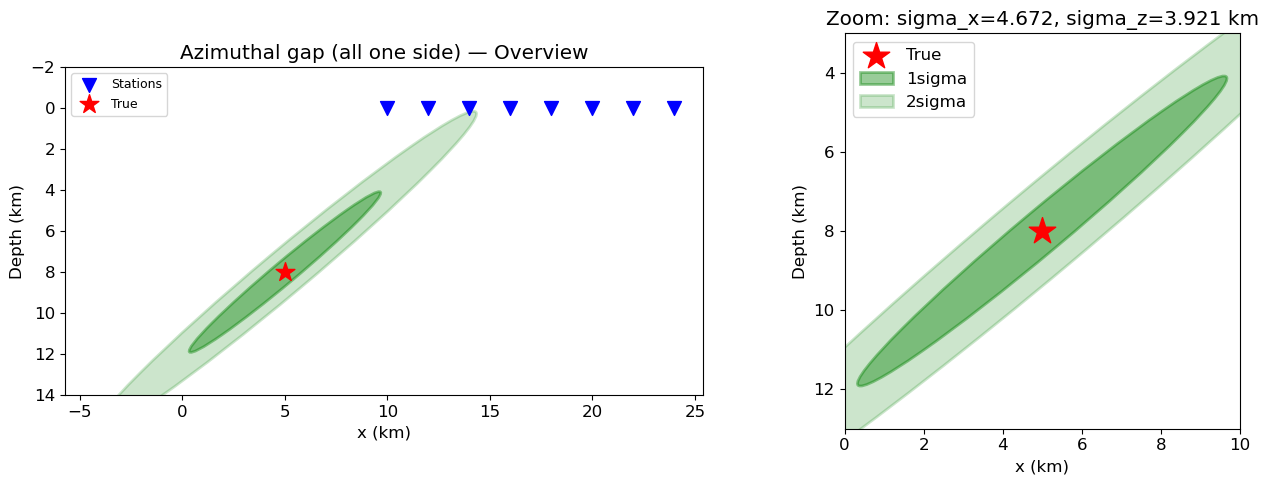

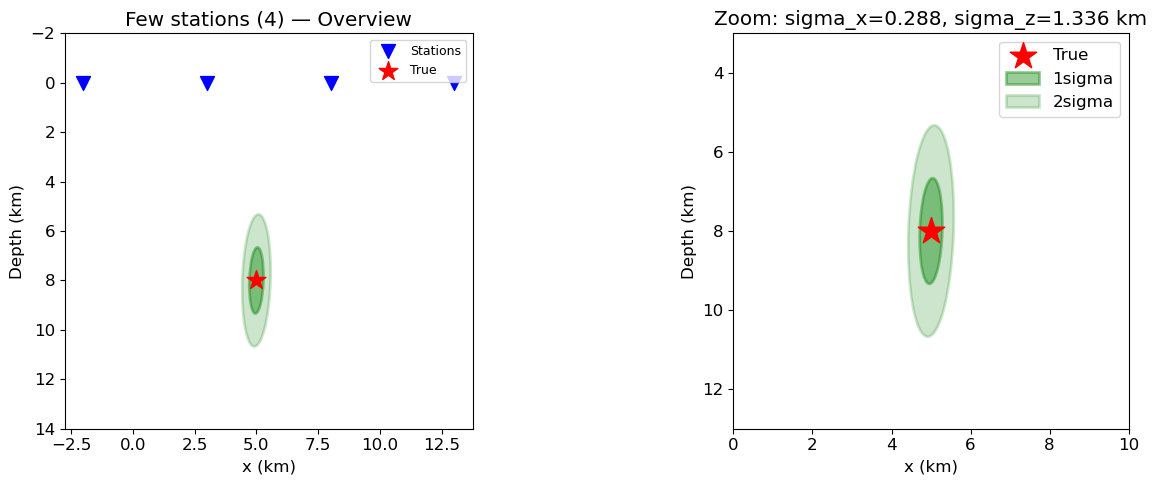

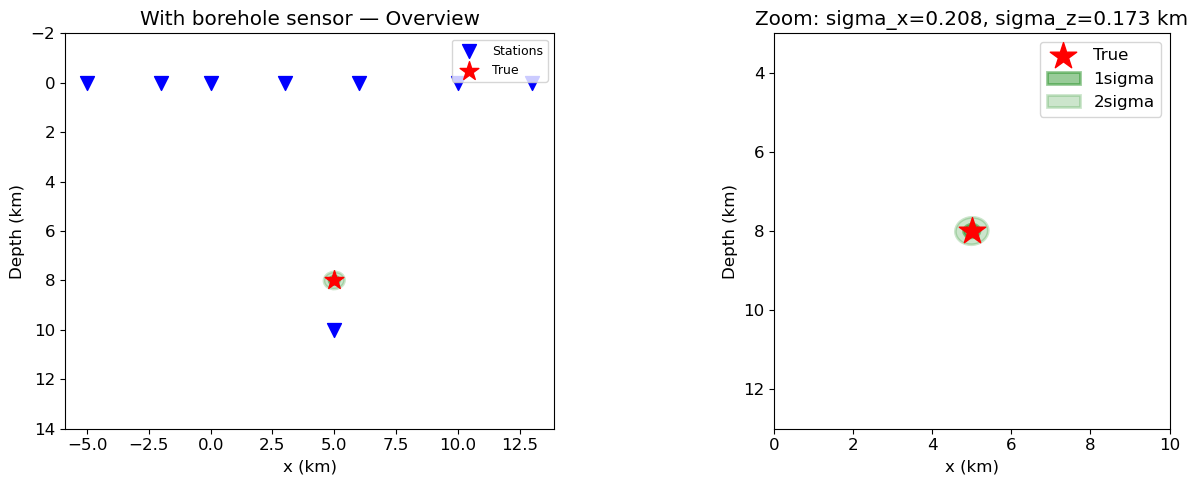

In [9]:
configs = [
    ("Good coverage (8 stations)", np.array([-5.,-2.,0.,3.,6.,10.,13.,15.]), np.zeros(8)),
    ("Azimuthal gap (all one side)", np.array([10.,12.,14.,16.,18.,20.,22.,24.]), np.zeros(8)),
    ("Few stations (4)", np.array([-2.,3.,8.,13.]), np.zeros(4)),
    ("With borehole sensor", np.array([-5.,-2.,0.,3.,6.,10.,13.,5.]), np.array([0.,0.,0.,0.,0.,0.,0.,10.])),
]

for title, sx, sz in configs:
    # Same formula, different station layout => different uncertainty
    G_cfg = compute_jacobian(x0_true, z0_true, v_true, sx, sz)
    Cm_cfg = np.linalg.inv(G_cfg.T @ G_cfg) * sigma_true**2
    Cm_xz_cfg = Cm_cfg[:2, :2]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.scatter(sx, sz, marker="v", s=100, c="blue", zorder=5, label="Stations")
    ax.scatter(x0_true, z0_true, marker="*", s=200, c="red", zorder=5, label="True")
    for ns, alpha in [(1, 0.4), (2, 0.2)]:
        plot_error_ellipse(ax, Cm_xz_cfg, (x0_true, z0_true), n_std=ns,
                           fill=True, facecolor="green", alpha=alpha, edgecolor="green", lw=2)
    ax.set_xlabel("x (km)"); ax.set_ylabel("Depth (km)")
    ax.set_title(f"{title} — Overview"); ax.set_ylim(14, -2); ax.set_aspect("equal"); ax.legend(fontsize=9)

    ax = axes[1]
    ax.scatter(x0_true, z0_true, marker="*", s=400, c="red", zorder=5, label="True")
    for ns, alpha in [(1, 0.4), (2, 0.2)]:
        plot_error_ellipse(ax, Cm_xz_cfg, (x0_true, z0_true), n_std=ns,
                           fill=True, facecolor="green", alpha=alpha, edgecolor="green", lw=2, label=f"{ns}sigma")
    ax.set_xlim(0, 10); ax.set_ylim(13, 3)
    ax.set_xlabel("x (km)"); ax.set_ylabel("Depth (km)")
    ax.set_title(f"Zoom: sigma_x={np.sqrt(Cm_cfg[0,0]):.3f}, sigma_z={np.sqrt(Cm_cfg[1,1]):.3f} km")
    ax.legend(); ax.set_aspect("equal")

    plt.tight_layout(); plt.show()

---
## 9. Chi-squared Goodness of Fit Test

The $\chi^2$ statistic measures whether our model fits the data:

$$\chi^2 = \sum_{i=1}^{n} \left(\frac{r^i}{\sigma}\right)^2$$

If the model is correct and errors are Gaussian, $\chi^2$ follows a **chi-squared distribution**
with $n_{\text{df}} = n_{\text{obs}} - n_{\text{params}}$ degrees of freedom.

- $\chi^2 \approx n_{\text{df}}$: good fit
- $\chi^2 \gg n_{\text{df}}$: poor fit (wrong model? bad picks?)
- $\chi^2 \ll n_{\text{df}}$: overfitting or overestimated $\sigma$

chi2 = 3.58,  n_df = 5
90% range: [1.15, 11.07]
In range? True


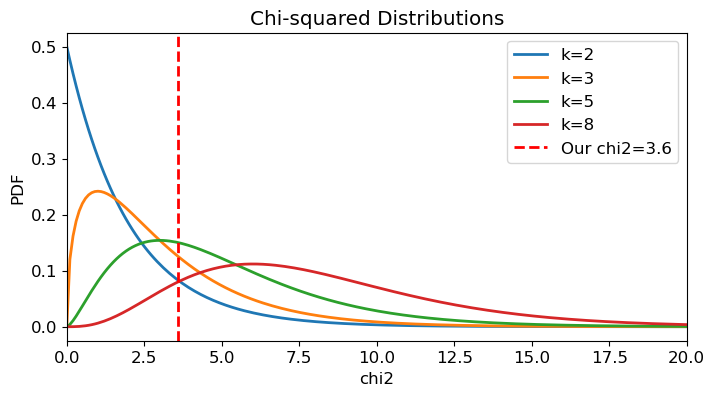


With wrong sigma:
  sigma=0.02: chi2=22.4, acceptable? False
  sigma=0.05: chi2=3.6, acceptable? True
  sigma=0.10: chi2=0.9, acceptable? False
  sigma=0.20: chi2=0.2, acceptable? False


In [10]:
# chi2 = sum of squared normalized residuals
n_df = n_stations - n_params
chi2_val = np.sum((r_final / sigma_true)**2)

print(f"chi2 = {chi2_val:.2f},  n_df = {n_df}")
print(f"90% range: [{chi2.ppf(0.05, n_df):.2f}, {chi2.ppf(0.95, n_df):.2f}]")
print(f"In range? {chi2.ppf(0.05, n_df) <= chi2_val <= chi2.ppf(0.95, n_df)}")

fig, ax = plt.subplots(figsize=(8, 4))
x_chi = np.linspace(0, 20, 200)
for k in [2, 3, 5, 8]:
    ax.plot(x_chi, chi2.pdf(x_chi, k), lw=2, label=f"k={k}")
ax.axvline(chi2_val, color="red", ls="--", lw=2, label=f"Our chi2={chi2_val:.1f}")
ax.set_xlabel("chi2"); ax.set_ylabel("PDF"); ax.set_title("Chi-squared Distributions")
ax.legend(); ax.set_xlim(0, 20); plt.show()

# What happens with wrong sigma?
print("\nWith wrong sigma:")
for s in [0.02, 0.05, 0.1, 0.2]:
    c = np.sum((r_final / s)**2)
    ok = chi2.ppf(0.05, n_df) <= c <= chi2.ppf(0.95, n_df)
    print(f"  sigma={s:.2f}: chi2={c:.1f}, acceptable? {ok}")

---
## 10. Aleatoric vs Epistemic Uncertainty

Two fundamentally different sources of error:

| | **Aleatoric** (random) | **Epistemic** (systematic) |
|---|---|---|
| Source | Random picking errors | Wrong velocity model |
| Captured by $\mathbf{C}_m$? | Yes | **No** |
| Reducible? | No (always present) | Yes (get better model) |

**Left**: 200 locations using the correct velocity — scatter is small and centered on truth.
**Right**: 200 locations using the wrong velocity (5.5 instead of 6.0 km/s) — locations are **biased** away from the true position. The error ellipse does NOT capture this bias.

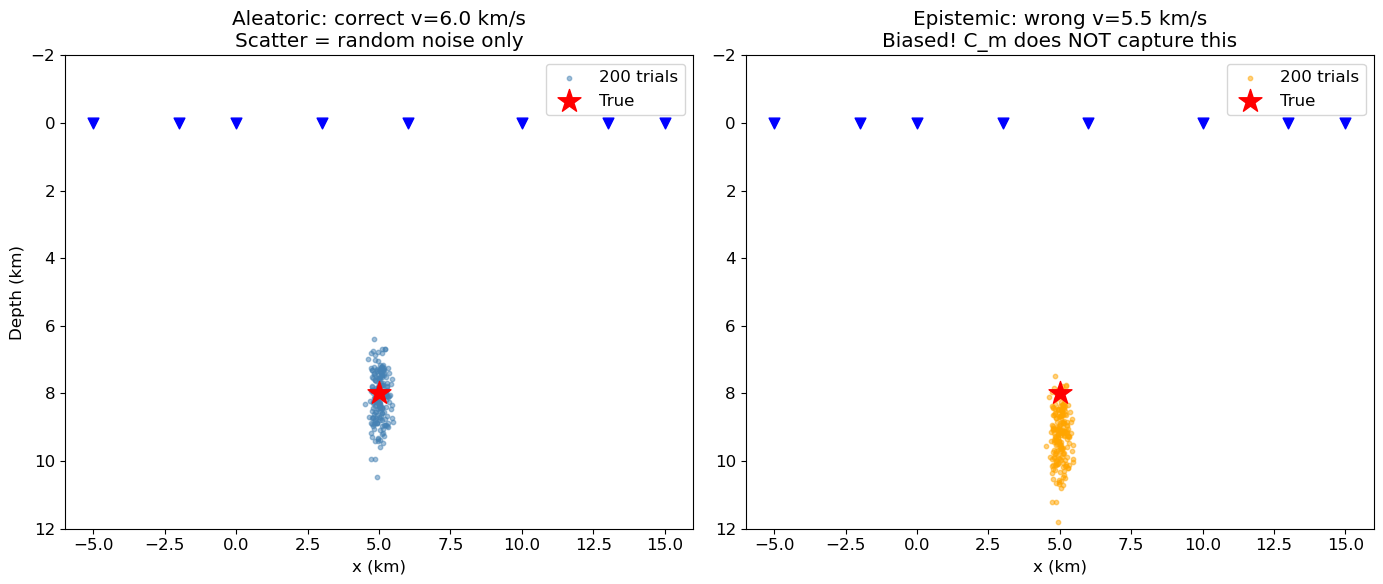

Aleatoric mean error: 0.621 km
Epistemic mean error: 1.306 km


In [11]:
# Run 200 trials: each time, add fresh random noise to the true arrival times and relocate.
# We suppress Geiger's iteration prints to keep output clean.
n_trials = 200
old_stdout = sys.stdout; sys.stdout = io.StringIO()  # suppress print output

locs_a, locs_e = [], []
for _ in range(n_trials):
    t_noisy = t_true + np.random.normal(0, sigma_true, n_stations)

    # Using the CORRECT velocity: scatter is small and centered on truth
    xa, za, _, _, _ = geiger_method(3., 6., 0.2, v_true, station_x, station_z, t_noisy, verbose=False)
    locs_a.append((xa, za))

    # Using the WRONG velocity (5.5 instead of 6.0): locations are systematically biased
    xe, ze, _, _, _ = geiger_method(3., 6., 0.2, 5.5, station_x, station_z, t_noisy, verbose=False)
    locs_e.append((xe, ze))

sys.stdout = old_stdout  # restore print output
locs_a = np.array(locs_a); locs_e = np.array(locs_e)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(station_x, np.zeros(n_stations), marker="v", s=60, c="blue", zorder=5)
ax.scatter(locs_a[:, 0], locs_a[:, 1], s=10, alpha=0.5, c="steelblue", label=f"{n_trials} trials")
ax.scatter(x0_true, z0_true, marker="*", s=300, c="red", zorder=5, label="True")
ax.set_title(f"Aleatoric: correct v={v_true} km/s\nScatter = random noise only")
ax.set_xlabel("x (km)"); ax.set_ylabel("Depth (km)"); ax.legend(); ax.set_ylim(12, -2)

ax = axes[1]
ax.scatter(station_x, np.zeros(n_stations), marker="v", s=60, c="blue", zorder=5)
ax.scatter(locs_e[:, 0], locs_e[:, 1], s=10, alpha=0.5, c="orange", label=f"{n_trials} trials")
ax.scatter(x0_true, z0_true, marker="*", s=300, c="red", zorder=5, label="True")
ax.set_title(f"Epistemic: wrong v=5.5 km/s\nBiased! C_m does NOT capture this")
ax.set_xlabel("x (km)"); ax.legend(); ax.set_ylim(12, -2)

plt.tight_layout(); plt.show()
print(f"Aleatoric mean error: {np.mean(np.sqrt((locs_a[:,0]-x0_true)**2+(locs_a[:,1]-z0_true)**2)):.3f} km")
print(f"Epistemic mean error: {np.mean(np.sqrt((locs_e[:,0]-x0_true)**2+(locs_e[:,1]-z0_true)**2)):.3f} km")

---
## 11. Comparing UQ Methods: Analytical (SVD) vs Bootstrap

Two ways to estimate location uncertainty:

1. **Analytical** (from least squares): $\mathbf{C}_m = (\mathbf{G}^T\mathbf{G})^{-1}\sigma^2$ → error ellipse
2. **Bootstrap**: resample stations with replacement, re-locate many times → spread of solutions = uncertainty

Both should give similar results when the assumptions hold (Gaussian errors, correct model).
Bootstrap is more flexible and works when analytical formulas are not available (e.g., for DD relocation).

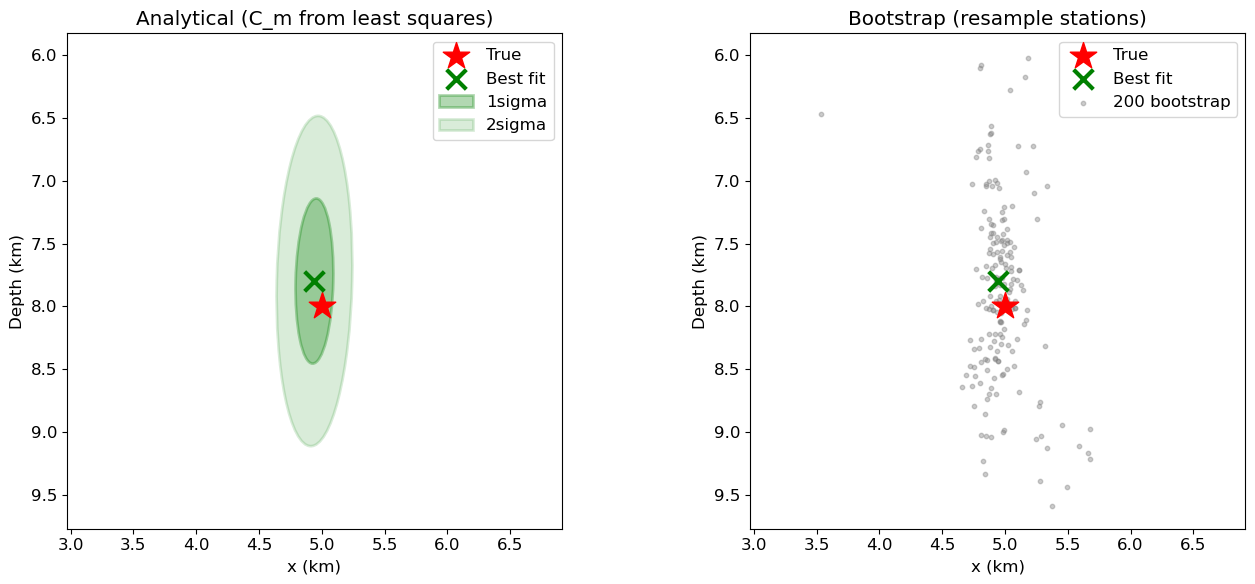

Analytical: sigma_x=0.1507, sigma_z=0.6574 km
Bootstrap:  sigma_x=0.4318, sigma_z=1.3207 km


In [12]:
# Bootstrap: randomly pick n stations WITH REPLACEMENT (so some appear twice, others not at all),
# relocate using that subset, and repeat many times. The spread of results = uncertainty.
n_boot = 200
old_stdout = sys.stdout; sys.stdout = io.StringIO()  # suppress print output
boot_locs = []
for _ in range(n_boot):
    idx = np.random.choice(n_stations, size=n_stations, replace=True)
    xb, zb, _, _, _ = geiger_method(
        x0_est, z0_est, t0_est, v_true,
        station_x[idx], station_z[idx], t_obs[idx], verbose=False)
    boot_locs.append((xb, zb))
sys.stdout = old_stdout  # restore print output
boot_locs = np.array(boot_locs)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, title in zip(axes, ["Analytical (C_m from least squares)", "Bootstrap (resample stations)"]):
    ax.scatter(x0_true, z0_true, marker="*", s=400, c="red", zorder=5, label="True")
    ax.scatter(x0_est, z0_est, marker="x", s=200, c="green", lw=3, zorder=5, label="Best fit")
    ax.set_xlabel("x (km)"); ax.set_ylabel("Depth (km)"); ax.set_title(title)

ax = axes[0]
for ns, alpha in [(1, 0.3), (2, 0.15)]:
    plot_error_ellipse(ax, Cm_xz, (x0_est, z0_est), n_std=ns,
                       fill=True, facecolor="green", alpha=alpha, edgecolor="green", lw=2, label=f"{ns}sigma")
m = max(3 * np.sqrt(Cm_xz[0, 0]), 3 * np.sqrt(Cm_xz[1, 1]), 0.5)
ax.set_xlim(x0_est - m, x0_est + m); ax.set_ylim(z0_est + m, z0_est - m)
ax.legend(); ax.set_aspect("equal")

ax = axes[1]
ax.scatter(boot_locs[:, 0], boot_locs[:, 1], s=10, alpha=0.4, c="gray", label=f"{n_boot} bootstrap")
ax.set_xlim(x0_est - m, x0_est + m); ax.set_ylim(z0_est + m, z0_est - m)
ax.legend(); ax.set_aspect("equal")

plt.tight_layout(); plt.show()
print(f"Analytical: sigma_x={np.sqrt(Cm_xz[0,0]):.4f}, sigma_z={np.sqrt(Cm_xz[1,1]):.4f} km")
print(f"Bootstrap:  sigma_x={np.std(boot_locs[:,0]):.4f}, sigma_z={np.std(boot_locs[:,1]):.4f} km")

---
---
# Part II: Relocation

In practice, the biggest source of location error is the **wrong velocity model** (epistemic uncertainty).
Nearby earthquakes share the same ray paths, so **differential arrival times cancel common errors**.

This section demonstrates:
- **Double-difference (DD)** relocation: uses differential times between event pairs
- **Station terms**: correct for systematic station bias
- **Cross-correlation**: measure differential times with sub-sample precision
- **Bootstrap UQ**: estimate uncertainty for relocated events

---
## 12. Setup: Multiple Events with Station Bias

We simulate 25 earthquakes on a strike-slip fault in 2D map view (x, y).
4 stations are scattered around the fault.

**Station bias** simulates the effect of unmodeled velocity heterogeneity:
each station has a systematic timing error that shifts all its arrival times.
This causes all locations to be shifted away from the true fault.

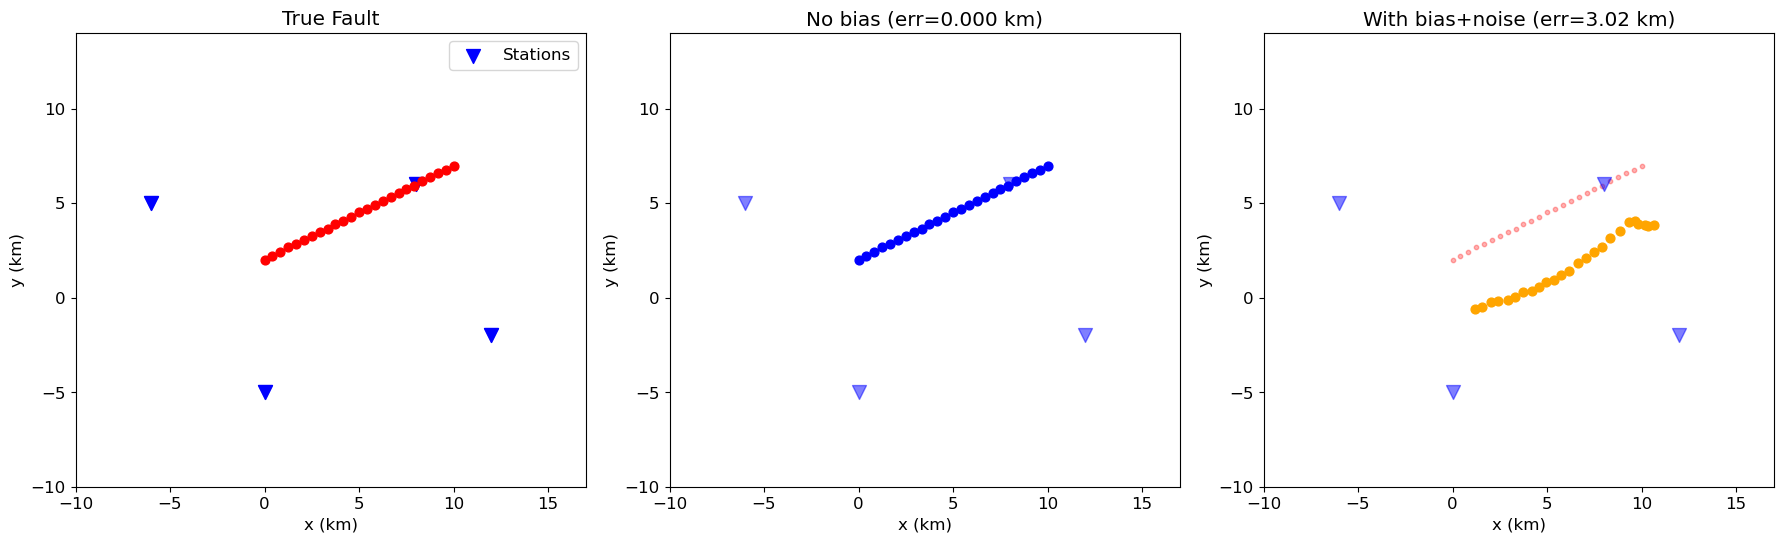

Station bias causes ~3.02 km average mislocation!


In [13]:
np.random.seed(42)
v2d = 6.0  # km/s

# Same functions as Part I, but in 2D map view (x, y) instead of cross-section (x, z)
def forward_2d(x0, y0, t0, v, sx, sy):
    return np.sqrt((sx - x0)**2 + (sy - y0)**2) / v + t0

def jacobian_2d(x0, y0, v, sx, sy):
    d = np.sqrt((sx - x0)**2 + (sy - y0)**2)
    return np.column_stack([-(sx - x0) / (v * d), -(sy - y0) / (v * d), np.ones(len(sx))])

def locate_2d(x0, y0, t0, v, sx, sy, tobs):
    """Geiger's method for one event in 2D (no print output)."""
    for _ in range(30):
        r = tobs - forward_2d(x0, y0, t0, v, sx, sy)
        G = jacobian_2d(x0, y0, v, sx, sy)
        dm = np.linalg.lstsq(G, r, rcond=None)[0]
        x0 += dm[0]; y0 += dm[1]; t0 += dm[2]
        if np.linalg.norm(dm) < 1e-8: break
    return x0, y0, t0

# 4 stations scattered around the study area
n_sta2d = 4
sta_x2d = np.array([-6., 0., 8., 12.])
sta_y2d = np.array([5., -5., 6., -2.])

# 25 earthquakes along a strike-slip fault
M2d = 25
fault_x = np.linspace(0, 10, M2d)
fault_y = 0.5 * fault_x + 2 + np.random.normal(0, 0.02, M2d)
eq_t0_2d = np.arange(M2d) * 5.0

# Station bias: in reality, the velocity model is wrong, so travel times through a slow/fast
# anomaly arrive late/early. We simulate this as a constant time offset per station.
sta_bias = np.array([0.4, -0.25, 0.3, -0.35])  # seconds
sigma_pick = 0.01  # 10 ms random picking noise

# Observations = true times + station bias + random noise
obs2d_clean = [forward_2d(fault_x[k], fault_y[k], eq_t0_2d[k], v2d, sta_x2d, sta_y2d) for k in range(M2d)]
noise_all   = [np.random.normal(0, sigma_pick, n_sta2d) for _ in range(M2d)]
obs2d_bias  = [obs2d_clean[k] + sta_bias + noise_all[k] for k in range(M2d)]

# Locate all events: without bias (perfect), and with bias (what we'd get in practice)
locs2d_clean, locs2d_biased_full = [], []
for k in range(M2d):
    xc, yc, _ = locate_2d(5., 5., eq_t0_2d[k], v2d, sta_x2d, sta_y2d, obs2d_clean[k])
    locs2d_clean.append((xc, yc))
    xb, yb, t0b = locate_2d(5., 5., eq_t0_2d[k], v2d, sta_x2d, sta_y2d, obs2d_bias[k])
    locs2d_biased_full.append((xb, yb, t0b))

locs2d_clean  = np.array(locs2d_clean)
locs2d_biased = np.array([(l[0], l[1]) for l in locs2d_biased_full])

err_c2d = np.mean(np.sqrt((locs2d_clean[:, 0] - fault_x)**2 + (locs2d_clean[:, 1] - fault_y)**2))
err_b2d = np.mean(np.sqrt((locs2d_biased[:, 0] - fault_x)**2 + (locs2d_biased[:, 1] - fault_y)**2))

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, data, color, title in [
    (axes[0], np.column_stack([fault_x, fault_y]), "red", "True Fault"),
    (axes[1], locs2d_clean, "blue", f"No bias (err={err_c2d:.3f} km)"),
    (axes[2], locs2d_biased, "orange", f"With bias+noise (err={err_b2d:.2f} km)"),
]:
    ax.scatter(data[:, 0], data[:, 1], c=color, s=40, zorder=5)
    ax.scatter(fault_x, fault_y, c="red", s=10, alpha=0.3)
    ax.scatter(sta_x2d, sta_y2d, marker="v", c="blue", s=100, zorder=4, alpha=0.5)
    ax.set_xlabel("x (km)"); ax.set_ylabel("y (km)")
    ax.set_title(title); ax.set_aspect("equal"); ax.set_xlim(-10, 17); ax.set_ylim(-10, 14)
axes[0].scatter(sta_x2d, sta_y2d, marker="v", c="blue", s=100, label="Stations"); axes[0].legend()
plt.tight_layout(); plt.show()

print(f"Station bias causes ~{err_b2d:.2f} km average mislocation!")

---
## 13. Double-Difference Relocation

**Key idea**: station bias affects both events equally, so it **cancels** in the differential time:

$$\Delta r_k^{ij} = (t_k^i - t_k^j)_{\text{obs}} - (\hat{t}_k^i - \hat{t}_k^j)_{\text{pred}}$$

We build a large sparse linear system $\mathbf{d} = \mathbf{G}\,\Delta\mathbf{m}$ where:
- $\mathbf{G}$ is $N_{\text{pairs}} \times 3M$ (sparse — only 6 non-zeros per row)
- $\Delta\mathbf{m}$ contains corrections for all $M$ events simultaneously

Solved iteratively with damped SVD (in practice, HypoDD uses LSQR for large systems).

DD system: 1076 observations, 75 parameters
Bias cancellation: max|dd_biased - dd_clean| = 4.51e-02


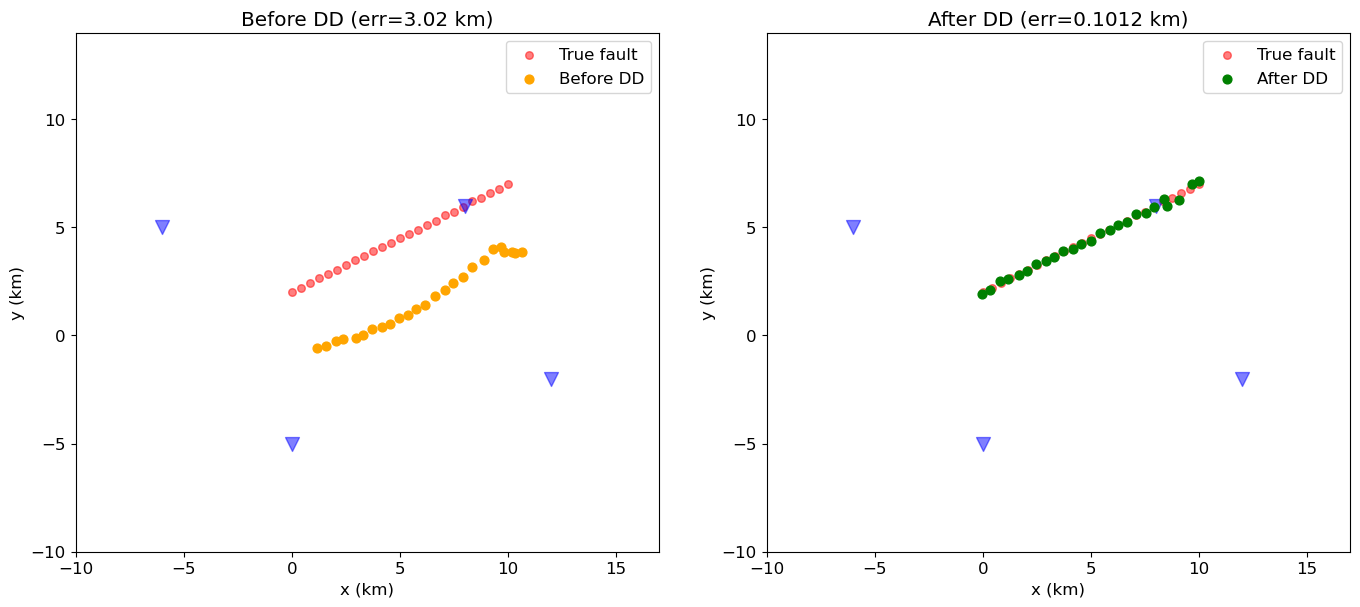

DD reduced error from 3.02 km to 0.1012 km


In [14]:
# For each pair of nearby events, compute the differential arrival time at each station.
# The station bias appears in both t_obs^i and t_obs^j, so it CANCELS in the difference.
pairs, dd_obs_list = [], []
for i in range(M2d):
    for j in range(i + 1, M2d):
        d_ij = np.sqrt((locs2d_biased[i, 0] - locs2d_biased[j, 0])**2 +
                       (locs2d_biased[i, 1] - locs2d_biased[j, 1])**2)
        if d_ij < 8.0:  # only pair events that are close
            for s in range(n_sta2d):
                pairs.append((i, j, s))
                dd_obs_list.append(obs2d_bias[i][s] - obs2d_bias[j][s])  # bias cancels here!

dd_obs = np.array(dd_obs_list)
n_dd = len(dd_obs)
print(f"DD system: {n_dd} observations, {3*M2d} parameters")

# Verify: the differential times are the same whether or not bias is present
dd_clean_check = np.array([obs2d_clean[i][s] - obs2d_clean[j][s] for i, j, s in pairs])
print(f"Bias cancellation: max|dd_biased - dd_clean| = {np.max(np.abs(dd_obs - dd_clean_check)):.2e}")

# Iterative DD solve: same idea as Geiger's method, but for ALL events simultaneously.
# The Jacobian G has one row per (pair, station) observation.
# Each row has only 6 non-zero entries: +[dt/dx, dt/dy, 1] for event i, -[same] for event j.
locs_dd2d = [list(l) for l in locs2d_biased_full]

for it in range(80):
    rows, cols, vals, dd_pred = [], [], [], []
    for idx, (i, j, s) in enumerate(pairs):
        xi, yi, t0i = locs_dd2d[i]
        xj, yj, t0j = locs_dd2d[j]
        dd_pred.append(forward_2d(xi, yi, t0i, v2d, sta_x2d[s], sta_y2d[s]) -
                       forward_2d(xj, yj, t0j, v2d, sta_x2d[s], sta_y2d[s]))

        # Jacobian row: partials for event i (positive) and event j (negative)
        di = np.sqrt((sta_x2d[s] - xi)**2 + (sta_y2d[s] - yi)**2)
        dj = np.sqrt((sta_x2d[s] - xj)**2 + (sta_y2d[s] - yj)**2)
        rows.extend([idx] * 6)
        cols.extend([3*i, 3*i+1, 3*i+2, 3*j, 3*j+1, 3*j+2])
        vals.extend([-(sta_x2d[s]-xi)/(v2d*di), -(sta_y2d[s]-yi)/(v2d*di), 1.,   # +event i
                      (sta_x2d[s]-xj)/(v2d*dj),  (sta_y2d[s]-yj)/(v2d*dj), -1.])  # -event j

    dd_res = dd_obs - np.array(dd_pred)
    G_dd_dense = csr_matrix((vals, (rows, cols)), shape=(n_dd, 3*M2d)).toarray()

    # Damped SVD: damping prevents instability from small singular values (null space).
    # We decrease damping over iterations so early steps are stable, later steps are precise.
    U_dd, s_dd, Vt_dd = np.linalg.svd(G_dd_dense, full_matrices=False)
    damp = max(0.01, 1.0 * 0.9**it)
    s_inv = s_dd / (s_dd**2 + damp**2)
    dm_dd = Vt_dd.T @ (s_inv * (U_dd.T @ dd_res))

    for k in range(M2d):
        locs_dd2d[k][0] += dm_dd[3*k]
        locs_dd2d[k][1] += dm_dd[3*k+1]
        locs_dd2d[k][2] += dm_dd[3*k+2]
    if np.linalg.norm(dm_dd) < 1e-6:
        break

locs_dd2d_arr = np.array([(l[0], l[1]) for l in locs_dd2d])
err_dd2d = np.mean(np.sqrt((locs_dd2d_arr[:, 0] - fault_x)**2 + (locs_dd2d_arr[:, 1] - fault_y)**2))

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(fault_x, fault_y, c="red", s=30, zorder=3, label="True fault", alpha=0.5)
ax.scatter(locs2d_biased[:, 0], locs2d_biased[:, 1], c="orange", s=40, zorder=5, label="Before DD")
ax.scatter(sta_x2d, sta_y2d, marker="v", c="blue", s=100, zorder=4, alpha=0.5)
ax.set_title(f"Before DD (err={err_b2d:.2f} km)"); ax.set_xlabel("x (km)"); ax.set_ylabel("y (km)")
ax.set_xlim(-10, 17); ax.set_ylim(-10, 14); ax.legend(); ax.set_aspect("equal")

ax = axes[1]
ax.scatter(fault_x, fault_y, c="red", s=30, zorder=3, label="True fault", alpha=0.5)
ax.scatter(locs_dd2d_arr[:, 0], locs_dd2d_arr[:, 1], c="green", s=40, zorder=5, label="After DD")
ax.scatter(sta_x2d, sta_y2d, marker="v", c="blue", s=100, zorder=4, alpha=0.5)
ax.set_title(f"After DD (err={err_dd2d:.4f} km)"); ax.set_xlabel("x (km)"); ax.set_ylabel("y (km)")
ax.set_xlim(-10, 17); ax.set_ylim(-10, 14); ax.legend(); ax.set_aspect("equal")

plt.tight_layout(); plt.show()
print(f"DD reduced error from {err_b2d:.2f} km to {err_dd2d:.4f} km")

---
## 14. Station Term Estimation

An alternative to DD: estimate and remove the **station bias** directly.

**Algorithm:**
1. Locate all events
2. Compute residuals at each station, averaged over all events
3. This average residual is the **station term** (captures systematic bias)
4. Subtract station terms from observations and relocate
5. Repeat until converged

Note: we apply a **zero-mean constraint** to the station terms to avoid ambiguity with origin time.

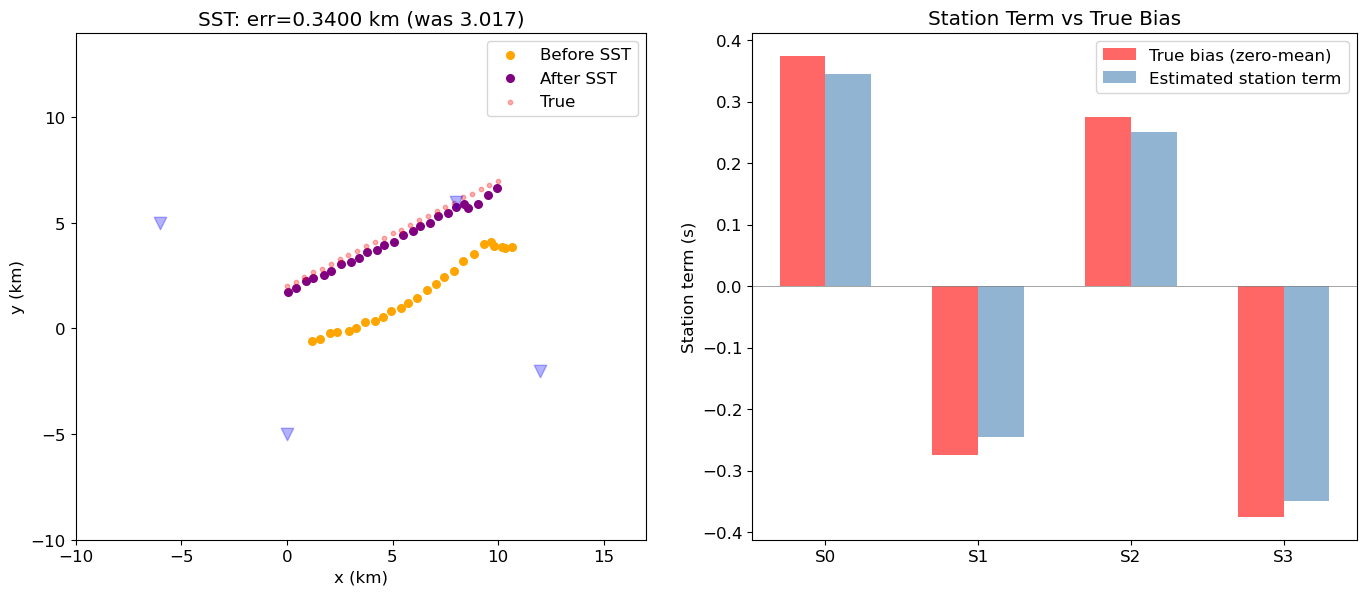

Before SST: err = 3.017 km
After SST:  err = 0.3400 km
Station term recovery error: max = 0.0302 s


In [15]:
# Iteratively estimate station terms and relocate:
#   Step 1: compute residuals at each station across all events
#   Step 2: average residual per station = station term (the systematic bias)
#   Step 3: subtract station terms from data, relocate all events, repeat

locs_sst2d = [list(l) for l in locs2d_biased_full]
station_term_2d = np.zeros(n_sta2d)

for it in range(50):
    # Step 1: residuals
    res = np.zeros((M2d, n_sta2d))
    for k in range(M2d):
        xi, yi, t0i = locs_sst2d[k]
        res[k] = obs2d_bias[k] - forward_2d(xi, yi, t0i, v2d, sta_x2d, sta_y2d)

    # Step 2: station term = average residual (captures the systematic part)
    station_term_2d = np.mean(res, axis=0)
    station_term_2d -= np.mean(station_term_2d)  # zero-mean constraint to avoid origin time ambiguity

    # Step 3: correct data and relocate
    for k in range(M2d):
        t_corr = obs2d_bias[k] - station_term_2d
        xk, yk, t0k = locate_2d(5., 5., eq_t0_2d[k], v2d, sta_x2d, sta_y2d, t_corr)
        locs_sst2d[k] = [xk, yk, t0k]

locs_sst2d_arr = np.array([(l[0], l[1]) for l in locs_sst2d])
err_sst2d = np.mean(np.sqrt((locs_sst2d_arr[:, 0] - fault_x)**2 + (locs_sst2d_arr[:, 1] - fault_y)**2))
bias_zm = sta_bias - np.mean(sta_bias)  # true bias with zero-mean for comparison

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(locs2d_biased[:, 0], locs2d_biased[:, 1], c="orange", s=30, label="Before SST")
ax.scatter(locs_sst2d_arr[:, 0], locs_sst2d_arr[:, 1], c="purple", s=30, label="After SST")
ax.scatter(fault_x, fault_y, c="red", s=10, alpha=0.3, label="True")
ax.scatter(sta_x2d, sta_y2d, marker="v", c="blue", s=80, alpha=0.3)
ax.set_title(f"SST: err={err_sst2d:.4f} km (was {err_b2d:.3f})")
ax.set_xlabel("x (km)"); ax.set_ylabel("y (km)")
ax.set_xlim(-10, 17); ax.set_ylim(-10, 14); ax.legend(); ax.set_aspect("equal")

ax = axes[1]
x_pos = np.arange(n_sta2d)
ax.bar(x_pos - 0.15, bias_zm, 0.3, color="red", alpha=0.6, label="True bias (zero-mean)")
ax.bar(x_pos + 0.15, station_term_2d, 0.3, color="steelblue", alpha=0.6, label="Estimated station term")
ax.set_xticks(x_pos); ax.set_xticklabels([f"S{i}" for i in range(n_sta2d)])
ax.set_ylabel("Station term (s)"); ax.set_title("Station Term vs True Bias")
ax.legend(); ax.axhline(0, color="gray", lw=0.5)

plt.tight_layout(); plt.show()
print(f"Before SST: err = {err_b2d:.3f} km")
print(f"After SST:  err = {err_sst2d:.4f} km")
print(f"Station term recovery error: max = {np.max(np.abs(station_term_2d - bias_zm)):.4f} s")

---
## 15. Waveform Cross-Correlation

**Cross-correlation** measures how similar two signals are as a function of time shift:

$$C(\tau) = \sum_t u(t) \, v(t + \tau)$$

The $\tau$ that maximizes $C$ is the **differential time** between two events.

**Why use cross-correlation instead of picking?**
- Phase picks: precision ~0.1 s
- Cross-correlation: precision ~**0.001 s** (sub-sample, via parabolic interpolation)
- Only works for **similar events** (nearby, similar mechanism)

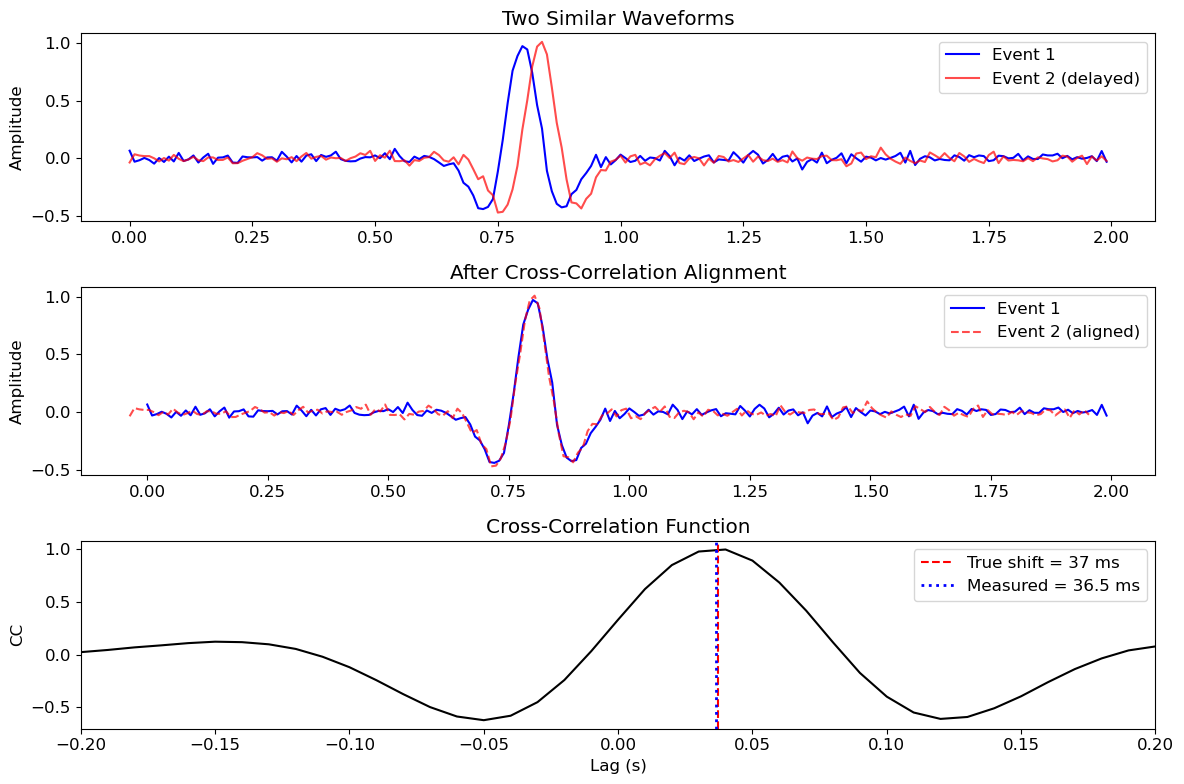

True shift: 37.0 ms, Measured: 36.5 ms, Error: 0.46 ms
Sample interval: 10 ms => sub-sample precision via parabolic interpolation!


In [16]:
dt_samp = 0.01; t_wave = np.arange(0, 2, dt_samp); f0 = 5.0

def ricker(t, t0, f):
    u = (np.pi * f * (t - t0))**2
    return (1 - 2 * u) * np.exp(-u)

# Two similar events: Event 2 arrives 37 ms later
true_shift = 0.037
w1 = ricker(t_wave, 0.8, f0) + 0.03 * np.random.randn(len(t_wave))
w2 = ricker(t_wave, 0.8 + true_shift, f0) + 0.03 * np.random.randn(len(t_wave))

# Cross-correlate: slide w2 past w1
cc = np.correlate(w2, w1, "full")
lags = np.arange(-len(w1) + 1, len(w1)) * dt_samp
cc /= np.max(np.abs(cc))

# Parabolic interpolation around the peak for sub-sample precision
pk = np.argmax(cc)
if 1 <= pk <= len(cc) - 2:
    y0, y1, y2 = cc[pk-1], cc[pk], cc[pk+1]
    d = 0.5 * (y0 - y2) / (y0 - 2*y1 + y2)
    measured_shift = lags[pk] + d * dt_samp
else:
    measured_shift = lags[pk]

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(t_wave, w1, "b-", label="Event 1")
axes[0].plot(t_wave, w2, "r-", alpha=0.7, label="Event 2 (delayed)")
axes[0].set_title("Two Similar Waveforms"); axes[0].legend(); axes[0].set_ylabel("Amplitude")

axes[1].plot(t_wave, w1, "b-", label="Event 1")
axes[1].plot(t_wave - measured_shift, w2, "r--", alpha=0.7, label="Event 2 (aligned)")
axes[1].set_title("After Cross-Correlation Alignment"); axes[1].legend(); axes[1].set_ylabel("Amplitude")

axes[2].plot(lags, cc, "k-")
axes[2].axvline(true_shift, color="red", ls="--", label=f"True shift = {true_shift*1000:.0f} ms")
axes[2].axvline(measured_shift, color="blue", ls=":", lw=2, label=f"Measured = {measured_shift*1000:.1f} ms")
axes[2].set_xlim(-0.2, 0.2); axes[2].set_xlabel("Lag (s)"); axes[2].set_ylabel("CC")
axes[2].set_title("Cross-Correlation Function"); axes[2].legend()

plt.tight_layout(); plt.show()
print(f"True shift: {true_shift*1000:.1f} ms, Measured: {measured_shift*1000:.1f} ms, Error: {abs(true_shift - measured_shift)*1000:.2f} ms")
print(f"Sample interval: {dt_samp*1000:.0f} ms => sub-sample precision via parabolic interpolation!")

---
## 16. Uncertainty Quantification for DD Relocation

For single-event location, UQ is easy: $\mathbf{C}_m = (\mathbf{G}^T\mathbf{G})^{-1}\sigma^2$ is a small $4 \times 4$ matrix.

For DD with $M$ events, $\mathbf{G}^T\mathbf{G}$ is $3M \times 3M$ — too large for direct inversion.

Two approaches:
1. **SVD** (works for small problems): decompose the DD Jacobian, compute $\mathbf{C}_m = \mathbf{V}\mathbf{S}^{-2}\mathbf{V}^T\sigma^2$
2. **Bootstrap** (works for any size): resample DD observations → re-solve → spread = uncertainty

We compare both methods below.

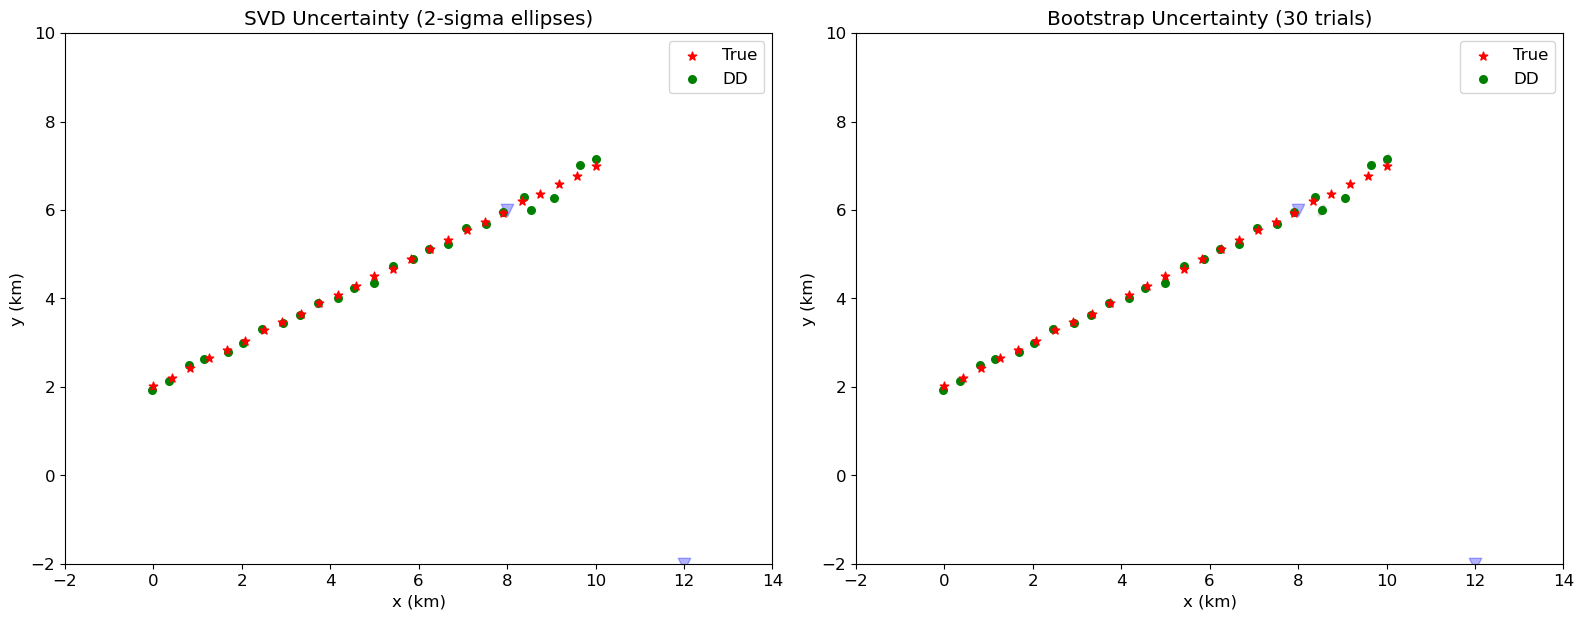

SVD  sigma_x: mean=0.0096 km, sigma_y: mean=0.0150 km
Boot sigma_x: mean=0.0089 km, sigma_y: mean=0.0140 km


In [17]:
# Two approaches to estimate uncertainty for DD relocation:
# 1) Analytical (SVD): C_m = V S^{-2} V^T * sigma^2  (same as single-event, just bigger matrix)
# 2) Bootstrap: resample DD observations, re-solve, measure the spread

# --- Approach 1: SVD ---
dd_res_final = dd_obs - np.array([
    forward_2d(locs_dd2d[i][0], locs_dd2d[i][1], locs_dd2d[i][2], v2d, sta_x2d[s], sta_y2d[s]) -
    forward_2d(locs_dd2d[j][0], locs_dd2d[j][1], locs_dd2d[j][2], v2d, sta_x2d[s], sta_y2d[s])
    for i, j, s in pairs])
sigma_dd_est = np.sqrt(np.sum(dd_res_final**2) / (n_dd - 3*M2d))
Cm_dd = Vt_dd.T @ np.diag(1 / s_dd**2) @ Vt_dd * sigma_dd_est**2

# --- Approach 2: Bootstrap ---
n_boot_dd = 30
boot_dd_sols = []
for b in range(n_boot_dd):
    # Resample DD observations with replacement
    idx = np.random.choice(n_dd, size=n_dd, replace=True)
    locs_boot = [list(l) for l in locs2d_biased_full]
    dd_obs_boot = dd_obs[idx]

    # Re-run the full DD inversion with the resampled data
    for it in range(50):
        rows, cols, vals, dd_pred = [], [], [], []
        pairs_boot = [pairs[ii] for ii in idx]
        for idx2, (i, j, s) in enumerate(pairs_boot):
            xi, yi, t0i = locs_boot[i]; xj, yj, t0j = locs_boot[j]
            dd_pred.append(forward_2d(xi, yi, t0i, v2d, sta_x2d[s], sta_y2d[s]) -
                           forward_2d(xj, yj, t0j, v2d, sta_x2d[s], sta_y2d[s]))
            di = np.sqrt((sta_x2d[s]-xi)**2 + (sta_y2d[s]-yi)**2)
            dj = np.sqrt((sta_x2d[s]-xj)**2 + (sta_y2d[s]-yj)**2)
            rows.extend([idx2]*6); cols.extend([3*i, 3*i+1, 3*i+2, 3*j, 3*j+1, 3*j+2])
            vals.extend([-(sta_x2d[s]-xi)/(v2d*di), -(sta_y2d[s]-yi)/(v2d*di), 1.,
                          (sta_x2d[s]-xj)/(v2d*dj),  (sta_y2d[s]-yj)/(v2d*dj), -1.])
        dd_r = dd_obs_boot - np.array(dd_pred)
        G_b = csr_matrix((vals, (rows, cols)), shape=(len(idx), 3*M2d)).toarray()
        U_b, s_b, Vt_b = np.linalg.svd(G_b, full_matrices=False)
        dmp = max(0.01, 1.0 * 0.9**it)
        dm = Vt_b.T @ ((s_b / (s_b**2 + dmp**2)) * (U_b.T @ dd_r))
        for k in range(M2d):
            locs_boot[k][0] += dm[3*k]; locs_boot[k][1] += dm[3*k+1]; locs_boot[k][2] += dm[3*k+2]
        if np.linalg.norm(dm) < 1e-6: break
    boot_dd_sols.append(np.array([(l[0], l[1]) for l in locs_boot]))
boot_dd_sols = np.array(boot_dd_sols)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.scatter(fault_x, fault_y, c="red", s=40, zorder=5, label="True", marker="*")
ax.scatter(locs_dd2d_arr[:, 0], locs_dd2d_arr[:, 1], c="green", s=30, zorder=4, label="DD")
for k in range(M2d):
    Cm_k = Cm_dd[3*k:3*k+2, 3*k:3*k+2]
    plot_error_ellipse(ax, Cm_k, (locs_dd2d_arr[k, 0], locs_dd2d_arr[k, 1]), n_std=2,
                       fill=True, facecolor="green", alpha=0.15, edgecolor="green", lw=0.5)
ax.scatter(sta_x2d, sta_y2d, marker="v", c="blue", s=80, alpha=0.3)
ax.set_title("SVD Uncertainty (2-sigma ellipses)"); ax.set_xlabel("x (km)"); ax.set_ylabel("y (km)")
ax.set_xlim(-2, 14); ax.set_ylim(-2, 10); ax.legend(); ax.set_aspect("equal")

ax = axes[1]
for b in range(n_boot_dd):
    ax.scatter(boot_dd_sols[b, :, 0], boot_dd_sols[b, :, 1], s=5, alpha=0.15, c="gray", zorder=1)
ax.scatter(fault_x, fault_y, c="red", s=40, zorder=5, label="True", marker="*")
ax.scatter(locs_dd2d_arr[:, 0], locs_dd2d_arr[:, 1], c="green", s=30, zorder=4, label="DD")
ax.scatter(sta_x2d, sta_y2d, marker="v", c="blue", s=80, alpha=0.3)
ax.set_title(f"Bootstrap Uncertainty ({n_boot_dd} trials)"); ax.set_xlabel("x (km)"); ax.set_ylabel("y (km)")
ax.set_xlim(-2, 14); ax.set_ylim(-2, 10); ax.legend(); ax.set_aspect("equal")

plt.tight_layout(); plt.show()

svd_sx = np.array([np.sqrt(Cm_dd[3*k, 3*k]) for k in range(M2d)])
svd_sy = np.array([np.sqrt(Cm_dd[3*k+1, 3*k+1]) for k in range(M2d)])
boot_sx = np.std(boot_dd_sols[:, :, 0], axis=0)
boot_sy = np.std(boot_dd_sols[:, :, 1], axis=0)
print(f"SVD  sigma_x: mean={np.mean(svd_sx):.4f} km, sigma_y: mean={np.mean(svd_sy):.4f} km")
print(f"Boot sigma_x: mean={np.mean(boot_sx):.4f} km, sigma_y: mean={np.mean(boot_sy):.4f} km")

---
## Summary

### Three Key Ideas

**1. Linear inversion for earthquake location:**

$$\mathbf{r} = \mathbf{G}\,\Delta\mathbf{m} \quad\Rightarrow\quad \Delta\mathbf{m} = (\mathbf{G}^T\mathbf{G})^{-1}\mathbf{G}^T\mathbf{r}$$

Iterate = Geiger's method. The Jacobian $\mathbf{G}$ contains partial derivatives of travel time w.r.t. source parameters.

**2. Uncertainty quantification:**

$$\mathbf{C}_m = (\mathbf{G}^T\mathbf{G})^{-1}\sigma^2 \quad\Rightarrow\quad \text{error ellipse}$$

Station geometry determines *shape*, data noise determines *size*. SVD reveals which directions are well/poorly resolved.

**3. Relocation = same equation, bigger matrix:**

| | Single event | Double-difference |
|---|---|---|
| $\mathbf{G}$ size | $n \times 4$ | $N_{\text{pairs}} \times 4M$ (sparse) |
| Solver | Direct / SVD | LSQR (iterative) |
| UQ | $\mathbf{C}_m$ directly | Bootstrap |
| Precision | ~100 m | ~10 m |